# Data Cleansing

## Import all requirements

In [8]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import missingno as msgn
import seaborn as sns
from matplotlib.dates import UTC
from seaborn import move_legend

url = './data/airbnb.csv'
airbnb = pd.read_csv(url)

## Separate the neighbourhood

In [9]:
place = airbnb['neighbourhood_full'].str.partition(',').drop(columns=1)
airbnb['District'] = place[0]
airbnb['Neighborhood'] = place[2]
airbnb = airbnb.drop(columns='neighbourhood_full')

## Price fixing


### Remove dollar sign

In [10]:
airbnb['price'] = airbnb['price'].str.replace('$', '', regex=False)

### Convert prices to numeric values FLOAT

In [11]:
airbnb['price'] = pd.to_numeric(airbnb['price'])
airbnb['price'] = airbnb['price'].fillna(airbnb.groupby(['Neighborhood','District'])['price'].transform('median'))

### Check in case there is a listing with unique placement

In [12]:
airbnb['price'] = airbnb['price'].fillna(airbnb['price'].median())

median = airbnb['price'].median()
airbnb.loc[airbnb['price'] <= 0, 'price'] = median
airbnb['price'].isna().any()

np.False_

### Remove unnecessary Id column and remove any ID duplicates form the dataframe

In [13]:
airbnb = airbnb.drop('Unnamed: 0', axis=1)
airbnb = airbnb.drop_duplicates(subset='listing_id', keep='first')

## Coordinates cleaning

In [ ]:
coords = airbnb['coordinates'].str.slice(1, -1).str.partition(',').drop(columns=1)
airbnb['longitude'] = coords[0].astype('float')
airbnb['latitude'] = coords[2].astype('float')
airbnb = airbnb.drop(columns='coordinates')

## Cleaning of the room types

In [ ]:
cleanup_rules = {
    'home': 'Entire home/apt',
    'Private': 'Private room',
    'PRIVATE ROOM': 'Private room',
    'Shared room': 'Shared room',
}

airbnb['room_type'] = airbnb['room_type'].str.strip().replace(cleanup_rules)

airbnb['room_type'].unique()

### Casting listing add data to datetime

In [ ]:
airbnb['listing_added'] = pd.to_datetime(airbnb['listing_added'])

airbnb['listing_added'].info()

## Mark not visited places

In [ ]:
airbnb['last_review'] = pd.to_datetime(airbnb['last_review'])

airbnb['visited'] = ~airbnb['last_review'].isna()

## Replace reviews per month with 0 if there are no reviews

In [ ]:
airbnb['reviews_per_month'] = airbnb['reviews_per_month'].fillna(airbnb['number_of_reviews'])

## Check availability and review's correctness

In [ ]:
airbnb.loc[airbnb['availability_365'] > 365, ['availability_365']] = 365

airbnb = airbnb[airbnb['availability_365'] <= 365]

### Check in case of wrongly calculated 5 start rating

In [ ]:
airbnb.loc[airbnb['5_stars'] > 5.0, ['5_stars']] = 5.0

## Fill the *Nan* house names with *House*

In [ ]:
airbnb['name'] = airbnb['name'].fillna('House')

## Drop the airbnbs without owners

In [ ]:
airbnb = airbnb.dropna(subset=['host_name'])

## Check if its okay

In [ ]:
msgn.matrix(airbnb, sort='ascending')
print(airbnb.isna().sum())

All missing review's columns are connected therefore it's probably caused by place simply not being visited / rated.

In [ ]:
airbnb

## Visualize using seaborn

In [ ]:
log_price = np.log1p(airbnb['price'])

sns.histplot(log_price, kde=True,bins=50)

airbnb['price_log'] = log_price

In [ ]:
airbnb['price_cut']= pd.cut(airbnb['price'], [0, 100 , 200, 300, 400, 500, 600, 1000, 1200, 5000, 8000])

# airbnb['price_cut'] = airbnb['price_cut'].value_counts()
# airbnb
sns.countplot(data=airbnb, y='price_cut', hue='room_type');

In [ ]:
sns.boxplot(data=airbnb, x='room_type', y='price_log', hue='room_type', legend=False);

In [ ]:
sns.boxenplot(airbnb, y='price_log', hue='room_type');

In [ ]:
sns.histplot(airbnb, x='price_log', hue='room_type', kde=True, alpha=0.5, bins=90,
                palette={'Private room': 'white', 'Entire home/apt': 'purple', 'Shared room': 'green'}
             )
plt.xlim(3,7);

In [ ]:
sns.histplot(airbnb[airbnb['room_type'] == 'Shared room'], x='price_log', kde=True, alpha=0.5, bins=90, hue='room_type');

In [ ]:
whole_dsc = airbnb.drop(['listing_id', 'host_id'], axis=1).groupby(airbnb['room_type']).describe()

price_dsc = airbnb['price'].groupby(airbnb['room_type']).describe()

price_dsc

In [ ]:
from skimpy import skim

print(skim(airbnb.drop(['listing_id','host_id', 'room_type', 'host_name', 'longitude', 'latitude'], axis=1)))

# HEATMAP

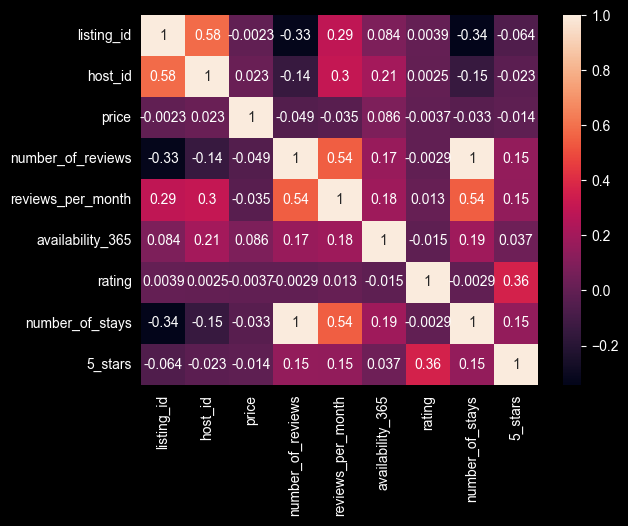

In [20]:
heat = airbnb.select_dtypes(include='number').corr()
sns.heatmap(heat , annot=True)
plt.show()

# Deletig one of two same columns (number_of_stays & number_of_reviews)


In [ ]:
airbnb = airbnb.drop(columns=['number_of_stays'] , inplace=True)

# Map of US thanks for scatterplot delete duplicated column

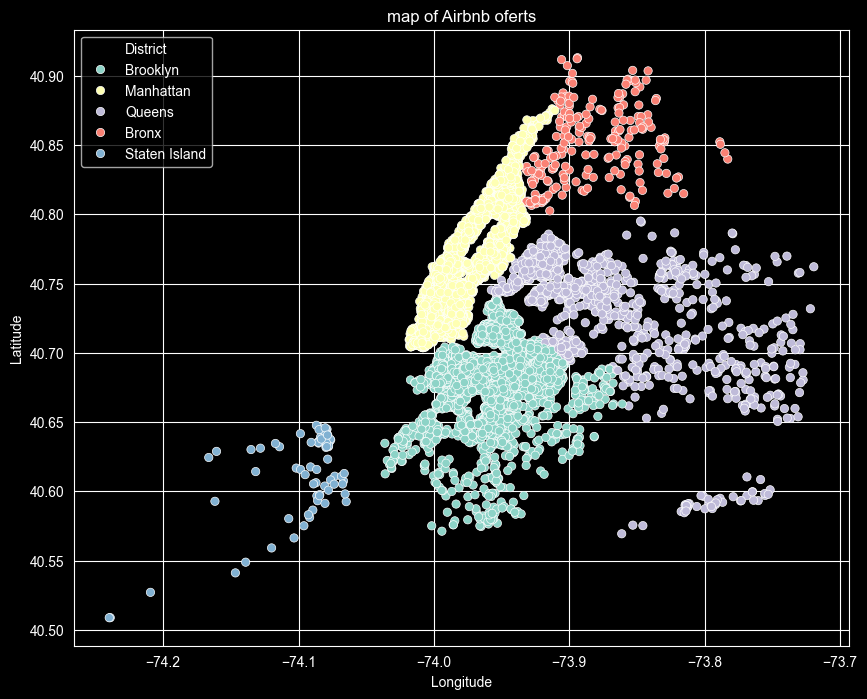

In [19]:

coords = airbnb['coordinates'].str.slice(1, -1).str.partition(',')
temp_latitude = coords[0].astype('float')
temp_longitude = coords[2].astype('float')


plt.figure(figsize=(10, 8))

sns.scatterplot(
    data=airbnb,
    x=temp_longitude,
    y=temp_latitude,
    hue='District'
)
plt.xlabel('Longitude')
plt.ylabel('Latitude')

plt.title('map of Airbnb oferts')
plt.show()